# 07 â€” Classification Model Comparison
LogReg(balanced) Â· RF Â· XGB(scale_pos_weight) Â· LGBM(is_unbalance) Â· SVC Â· KNN, 5-fold CV. Primary metric: PR-AUC.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd
from src.config import SPLITS_DIR, RESULTS_DIR, FEATURES, TARGET_CLF
from src.models import clf_models, CLF_NAMES
from src.evaluate import evaluate_target, leaderboard_row

train = pd.read_csv(SPLITS_DIR / "train.csv")
X = train[FEATURES]
y = train[TARGET_CLF].astype(int)
factories = clf_models((y == 1).sum(), (y == 0).sum())
rows = []
for name in CLF_NAMES:
    scores = evaluate_target("clf", factories[name], X, y)
    row = leaderboard_row(name, TARGET_CLF, "clf", scores)
    rows.append(row)
    print(name, "-> pr_auc", row["pr_auc_mean"], "f1", row["f1_mean"], flush=True)
clf_cv = pd.DataFrame(rows)
clf_cv.to_csv(RESULTS_DIR / "clf_baseline_cv.csv", index=False)
clf_cv.sort_values("pr_auc_mean", ascending=False)


logistic_regression -> pr_auc 0.77658 f1 0.7183


random_forest -> pr_auc 0.87266 f1 0.79219


xgboost -> pr_auc 0.84228 f1 0.77739


lightgbm -> pr_auc 0.85117 f1 0.78153


E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


...

E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svc -> pr_auc 0.81211 f1 0.77999


knn -> pr_auc 0.78186 f1 0.78033


,model,target,pr_auc_mean,pr_auc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,primary_metric,primary_value
1,random_forest,next_is_irregular,0.87266,0.02337,0.79219,0.03146,0.96897,0.00567,pr_auc,0.87266
3,lightgbm,next_is_irregular,0.85117,0.02303,0.78153,0.02263,0.95723,0.01006,pr_auc,0.85117
2,xgboost,next_is_irregular,0.84228,0.02390,0.77739,0.01810,0.95292,0.00813,pr_auc,0.84228
4,svc,next_is_irregular,0.81211,0.04107,0.77999,0.02508,0.95790,0.00807,pr_auc,0.81211
5,knn,next_is_irregular,0.78186,0.04307,0.78033,0.02981,0.91431,0.02025,pr_auc,0.78186
0,logistic_regression,next_is_irregular,0.77658,0.01800,0.71830,0.02124,0.94317,0.01208,pr_auc,0.77658


## Added diagnostics — per-fold CV boxplots\nFold-level PR-AUC / F1 distributions per model; variance here qualifies the mean reported in the leaderboard.

logistic_regression fold PR-AUCs: [0.75  0.797 0.786 0.769 0.781]


random_forest fold PR-AUCs: [0.835 0.883 0.865 0.888 0.892]


xgboost fold PR-AUCs: [0.803 0.861 0.837 0.858 0.853]


lightgbm fold PR-AUCs: [0.813 0.871 0.851 0.853 0.868]


E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


...

E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


E:\NAVYA_MODEL\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svc fold PR-AUCs: [0.744 0.812 0.827 0.826 0.853]


knn fold PR-AUCs: [0.71  0.808 0.78  0.792 0.82 ]


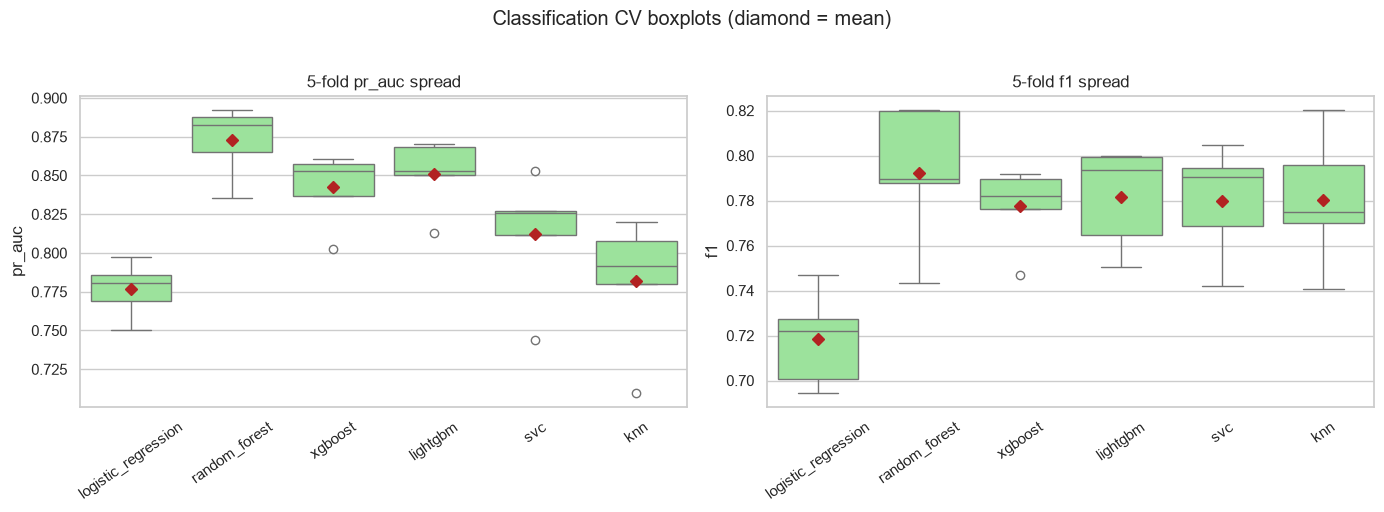

pr_auc              f1         roc_auc        
                       mean     std    mean     std    mean     std
model                                                              
knn                  0.7819  0.0431  0.7803  0.0298  0.9143  0.0203
lightgbm             0.8512  0.0230  0.7815  0.0226  0.9572  0.0101
logistic_regression  0.7766  0.0180  0.7183  0.0212  0.9432  0.0121
random_forest        0.8727  0.0234  0.7922  0.0315  0.9690  0.0057
svc                  0.8121  0.0411  0.7800  0.0251  0.9579  0.0081
xgboost              0.8423  0.0239  0.7774  0.0181  0.9529  0.0081

In [2]:
train = pd.read_csv(SPLITS_DIR / "train.csv")
X = train[FEATURES]
y = train[TARGET_CLF].astype(int)
factories = clf_models((y == 1).sum(), (y == 0).sum())
rows = []
for name in CLF_NAMES:
    folds = cv_classification_folds(factories[name], X, y)
    for i, m in enumerate(folds, 1):
        rows.append({"model": name, "fold": i,
                     "pr_auc": m["pr_auc"], "f1": m["f1"], "roc_auc": m["roc_auc"]})
    print(name, "fold PR-AUCs:", np.round([m["pr_auc"] for m in folds], 3), flush=True)
fold_df = pd.DataFrame(rows)
fold_df.to_csv(RESULTS_DIR / "clf_fold_scores.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["pr_auc", "f1"]):
    sns.boxplot(data=fold_df, x="model", y=metric, ax=ax, color="lightgreen",
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "firebrick", "markeredgecolor": "firebrick"})
    ax.set_title(f"5-fold {metric} spread"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
plt.suptitle("Classification CV boxplots (diamond = mean)", y=1.02)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "cv_boxplots_classification.png", dpi=150, bbox_inches="tight"); plt.show()

spread = fold_df.groupby("model")[["pr_auc", "f1", "roc_auc"]].agg(["mean", "std"]).round(4)
display(spread)
